In [71]:
import sklearn
import shap
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from sklearn.model_selection import train_test_split
from sklearn.cluster import HDBSCAN
from sklearn.ensemble import RandomForestClassifier
from sklearn.multiclass import OneVsRestClassifier
from sklearn.manifold import TSNE
import torch.nn as nn
import torch
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import medal
import pickle
import umap
import hdbscan

In [2]:
with open("./shap/shap_on_real_dist/model.pkl",'rb') as file:
    model=pickle.load(file)

In [38]:
with open("shap/shap_on_real_dist/sv_kern_recon.pkl",'rb') as file:
    shap_values_kernel=pickle.load(file)

In [42]:
with open("shap/shap_on_real_dist/sv_kern_lat0.pkl",'rb') as file:
    shap_values_lat0_kernel=pickle.load(file)

In [43]:
with open("shap/shap_on_real_dist/sv_kern_lat1.pkl",'rb') as file:
    shap_values_lat1_kernel=pickle.load(file)

In [44]:
with open("shap/shap_on_real_dist/sv_samp_lat1.pkl",'rb') as file:
    shap_values_lat0_samp=pickle.load(file)
with open("shap/shap_on_real_dist/sv_samp_lat1.pkl",'rb') as file:
    shap_values_lat1_samp=pickle.load(file)

In [45]:
with open("shap/shap_on_real_dist/sv_perm_recon.pkl",'rb') as file:
    shap_values_perm=pickle.load(file)
with open("shap/shap_on_real_dist/sv_perm_lat0.pkl",'rb') as file:
    shap_values_lat0_perm=pickle.load(file)
with open("shap/shap_on_real_dist/sv_perm_lat1.pkl",'rb') as file:
    shap_values_lat1_perm=pickle.load(file)

In [46]:
with open("shap/shap_on_real_dist/sv_samp_recon.pkl",'rb') as file:
    shap_values_samp=pickle.load(file)
with open("shap/shap_on_real_dist/sv_samp_lat0.pkl",'rb') as file:
    shap_values_lat0_samp=pickle.load(file)
with open("shap/shap_on_real_dist/sv_samp_lat1.pkl",'rb') as file:
    shap_values_lat1_samp=pickle.load(file)

In [7]:
(x_train, y_train), (x_test, y_test)=mnist.load_data()
x_train=x_train.reshape(x_train.shape[0],-1)[0:10000]
y_train=y_train[0:10000]
x_test=x_test.reshape(x_test.shape[0],-1)[:100]
y_test=y_test[:100]

x_train=x_train/255.0
x_test=x_test/255.0

x_train_tensor=torch.from_numpy(x_train).float()
x_train_tensor=torch.utils.data.TensorDataset(x_train_tensor)
x_test_tensor=torch.from_numpy(x_test).float()
x_test_tensor=torch.utils.data.TensorDataset(x_test_tensor)

train_loader=torch.utils.data.DataLoader(x_train_tensor, batch_size=128)
test_loader=torch.utils.data.DataLoader(x_test_tensor, batch_size=100)

In [9]:
train_batch=next(iter(train_loader))
train_image, *smth=train_batch
print(train_image.size())

test_batch=next(iter(test_loader))
test_image, *smth=test_batch
print(test_image.size())

b_size=128
t_size=100

background=train_image[:b_size]
test=test_image[:t_size]

torch.Size([128, 784])
torch.Size([100, 784])


In [9]:
### train autoencoder umap
model=medal.MEDAL(
    input_dim=784,
    latent_dim=2,
    hidden_dims=(1024,1024,1024,1024),
)
teacher_embedding=medal.get_teacher_embeddings(
    "umap",
    x_train,
    n_neighbors=35
)
model.fit(x_train, teacher_embedding)
recon_loss=medal.compute_losses(
    model.model,
    x_train,
    teacher_embedding
)

/insomnia001/depts/iicd/users/vj2308/miniconda/envs/medal/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
  0%|                                                                    | 0/100 [00:00<?, ?it/s]/insomnia001/depts/iicd/users/vj2308/miniconda/envs/medal/lib/python3.10/site-packages/ray/train/_internal/session.py:676: UserWarning: `report` is meant to only be called inside a function that is executed by a Tuner or Trainer. Returning `None`.
  warnings.warn(
100%|██████████████████████████████████████████████████████████| 100/100 [10:55<00:00,  6.55s/it]


In [10]:
with open("./shap/shap_on_real_dist/model.pkl",'wb') as file:
    pickle.dump(model, file)

In [81]:
### build wrapper
def recon_error(x):
    if not isinstance(x, torch.Tensor):
        x=torch.from_numpy(np.asarray(x, dtype=np.float32))
    x=x.detach()
    with torch.no_grad():
        x_recon,_=model.model(x)
        err=((x-x_recon)**2).mean(dim=1)
    return err.cpu().numpy()
    
def latent_wrapper_dim0(x):
    if not isinstance(x, torch.Tensor):
        x=torch.from_numpy(np.asarray(x, dtype=np.float32)) 
    x=x.detach()
    with torch.no_grad():
        _, x_latent=model.model(x)
    return x_latent[:, 0].cpu().numpy()

def latent_wrapper_dim1(x):
    if not isinstance(x, torch.Tensor):
        x=torch.from_numpy(np.asarray(x, dtype=np.float32)) 
    x=x.detach()
    with torch.no_grad():
        _, x_latent=model.model(x)
    return x_latent[:, 1].cpu().numpy()

class ModelWrapper_recon(nn.Module):
    def __init__(self, autoencoder):
        super().__init__()
        self.autoencoder=autoencoder

    def forward(self, x):
        x_recon,_=self.autoencoder(x)
        diff=(x-x_recon).view(x.size(0), -1)
        err=(diff**2).sum(dim=1)
        return err.unsqueeze(1)

class ModelWrapper_lat0(nn.Module):
    def __init__(self, autoencoder):
        super().__init__()
        self.autoencoder=autoencoder

    def forward(self, x):
        _, x_latent=self.autoencoder(x)
        return x_latent[:, 0:1]

class ModelWrapper_lat1(nn.Module):
    def __init__(self, autoencoder):
        super().__init__()
        self.autoencoder=autoencoder

    def forward(self, x):
        _, x_latent=self.autoencoder(x)
        return x_latent[:, 1:2]

class ModelWrapper(nn.Module):
    def __init__(self, autoencoder):
        super().__init__()
        self.autoencoder=autoencoder

    def forward(self, x):
        x_recon,_=self.autoencoder(x)
        return x_recon

In [94]:
# overlaying the features above on original data image
def overlay_features(shap_values_list, title, top_k=10):
    fig, ax=plt.subplots(2,5,figsize=(10,5))
    for i in range(10):
        shap_val=shap_values_list[i][0]
        shap_image=shap_val.reshape(28,28)
        og_image=x_test[y_test==i][0].reshape(28,28)

        top_indices=np.argsort(np.abs(shap_val), axis=None)[-top_k:]
        top_y,top_x=np.unravel_index(top_indices,(28,28))

        colors=np.zeros((28,28,3), dtype=float)
        for y,x in zip(top_y,top_x):
            if shap_val[y*28+x]>0:
                colors[y,x]=[1,0,0]  #red
            else:
                colors[y,x]=[0,0,1]  #blue
        ax[i//5, i%5].imshow(og_image, cmap="gray")
        ax[i//5, i%5].imshow(colors, alpha=0.6)
        #ax[i//5, i%5].set_title(f"digit {i} and top {top_k} contributing pixels")
        ax[i//5, i%5].axis("off")
    fig.suptitle(title)

def global_overlay_features(shap_values_mean, title, top_k=10):
    fig, ax=plt.subplots(2,5,figsize=(10,5))
    for i in range(10):
        shap_val=shap_values_mean[i]
        shap_image=shap_val.reshape(28,28)
        og_image=x_test[y_test==i].mean(axis=0).reshape(28,28)

        top_indices=np.argsort(np.abs(shap_val), axis=None)[-top_k:]
        top_y,top_x=np.unravel_index(top_indices,(28,28))

        colors=np.zeros((28,28,3), dtype=float)
        for y,x in zip(top_y,top_x):
            if shap_val[y*28+x]>0:
                colors[y,x]=[1,0,0]  #red
            else:
                colors[y,x]=[0,0,1]  #blue
        ax[i//5, i%5].imshow(og_image, cmap="gray")
        ax[i//5, i%5].imshow(colors, alpha=0.6)
        #ax[i//5, i%5].set_title(f"digit {i} and top {top_k} contributing pixels")
        ax[i//5, i%5].axis("off")
    fig.suptitle(title)

In [ ]:
### kernel

## kernel explainer for recon
shap_values_kernel=[]
for i in range(10):
    batch=min(len(x_train[y_train==i]), 128)
    explainer=shap.KernelExplainer(
        recon_error,
        x_train[y_train==i][:batch]
    )    
    shap_values=explainer.shap_values(x_test[y_test==i])
    shap_values_kernel.append(shap_values)

In [29]:
with open("shap/shap_on_real_dist/sv_kern_recon.pkl","wb") as file:
    pickle.dump(shap_values_kernel, file)

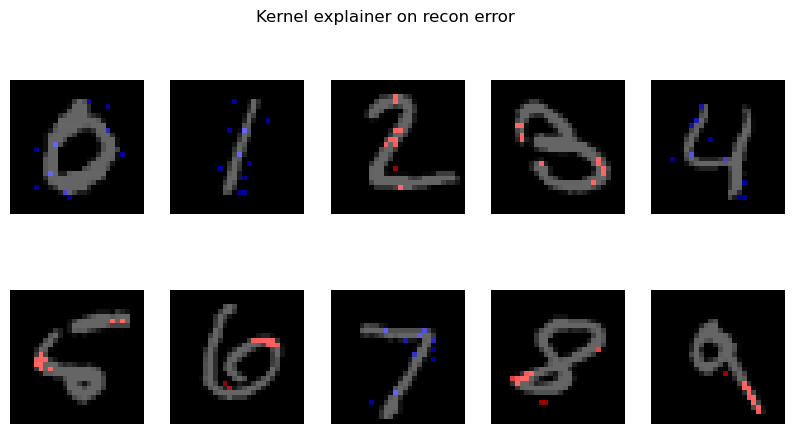

In [41]:
overlay_features(shap_values_kernel, "Kernel explainer on recon error", 10)

In [ ]:
## kernel explainer for latent dims
shap_values_lat0_kernel=[]
shap_values_lat1_kernel=[]
for i in range(10):
    batch=min(len(x_train[y_train==i]), 128)
    explainer=shap.KernelExplainer(
        latent_wrapper_dim0,
        x_train[y_train==i][:batch]
    )    
    shap_values=explainer.shap_values(x_test[y_test==i])
    shap_values_lat0_kernel.append(shap_values)

    explainer=shap.KernelExplainer(
        latent_wrapper_dim1,
        x_train[y_train==i][:batch]
    )    
    shap_values=explainer.shap_values(x_test[y_test==i])
    shap_values_lat1_kernel.append(shap_values)

In [39]:
with open("shap/shap_on_real_dist/sv_kern_lat0.pkl","wb") as file:
    pickle.dump(shap_values_lat0_kernel, file)
with open("shap/shap_on_real_dist/sv_kern_lat1.pkl","wb") as file:
    pickle.dump(shap_values_lat1_kernel, file)

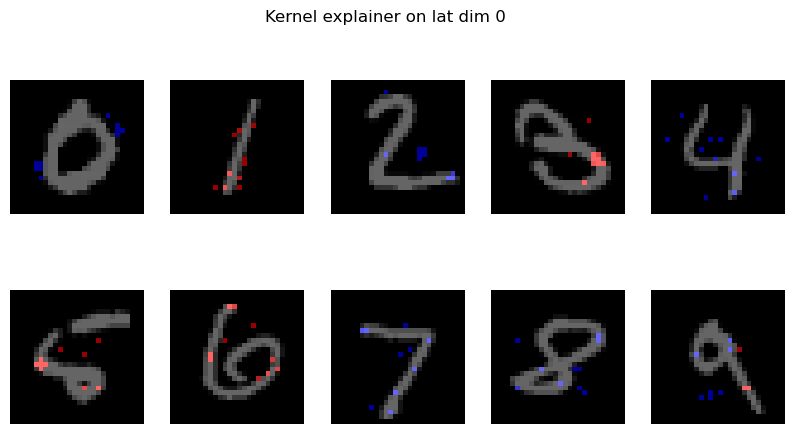

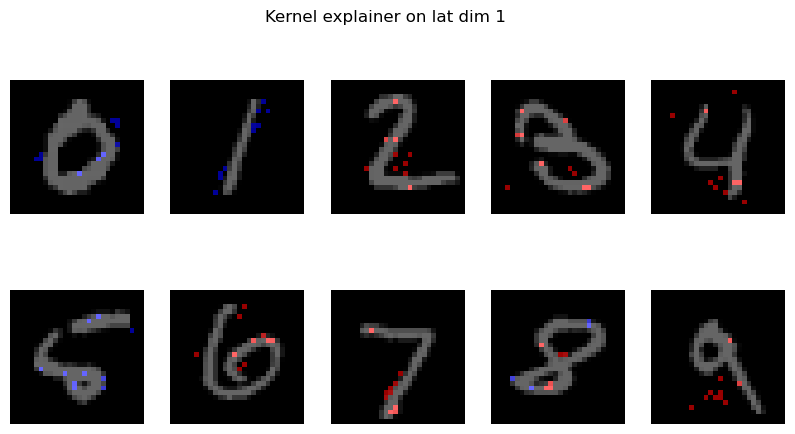

In [47]:
overlay_features(shap_values_lat0_kernel, "Kernel explainer on lat dim 0", 10)
overlay_features(shap_values_lat1_kernel, "Kernel explainer on lat dim 1", 10)

In [72]:
x_train_tensor=torch.from_numpy(x_train).float()
x_train_tensor=torch.utils.data.TensorDataset(x_train_tensor)
x_test_tensor=torch.from_numpy(x_test).float()
x_test_tensor=torch.utils.data.TensorDataset(x_test_tensor)

train_loader=torch.utils.data.DataLoader(x_train_tensor, batch_size=128)
test_loader=torch.utils.data.DataLoader(x_test_tensor, batch_size=100)

test_batch=next(iter(test_loader))
test_image, *smth=test_batch
print(test_image.size())

torch.Size([100, 784])


In [16]:
### deep explainer
#currently returns error saying that SHAP values do not add up to models output
shap.explainers._deep.DeepExplainer.check_additivity = False
wrapped_model=ModelWrapper_recon(model.model)

## recon
shap_values_deep=[]
for i in range(10):
    batch=min(len(x_train[y_train==i]), 128)
    ten=torch.tensor(x_train[y_train==i][:batch], dtype=torch.float32)
    explainer=shap.DeepExplainer(
        wrapped_model.eval(),
        ten
    )    
    test_ten=torch.tensor(x_test[y_test==i], dtype=torch.float32)
    '''
    print(ten.shape, test_ten.shape)
    out_bg=wrapped_model(ten)
    out_test=wrapped_model(test_ten[:5])
    print(out_bg.shape, out_test.shape)
    '''

    shap_values=explainer.shap_values(test_ten)
    shap_values_deep.append(shap_values)

TypeError: DeepExplainer.__init__() got an unexpected keyword argument 'check_additivity'

In [12]:
### permutation explainer

## recon
shap_values_perm=[]
for i in range(10):
    batch=min(len(x_train[y_train==i]), 128)
    explainer=shap.PermutationExplainer(
        recon_error,
        x_train[y_train==i][:batch]
    )    
    shap_values=explainer.shap_values(x_test[y_test==i])
    shap_values_perm.append(shap_values)

PermutationExplainer explainer: 9it [01:29, 11.18s/it]                                           
PermutationExplainer explainer: 15it [01:58,  9.11s/it]                                          
PermutationExplainer explainer: 9it [01:22, 10.26s/it]                                           
PermutationExplainer explainer: 12it [01:47,  9.81s/it]                                          
PermutationExplainer explainer: 15it [02:07,  9.80s/it]                                          
PermutationExplainer explainer: 8it [01:08, 11.39s/it]                                           
PermutationExplainer explainer: 11it [01:45, 10.58s/it]                                          
PermutationExplainer explainer: 16it [02:05,  8.98s/it]                                          
PermutationExplainer explainer: 3it [00:20, 20.12s/it]                                           
PermutationExplainer explainer: 12it [01:53, 11.35s/it]                                          


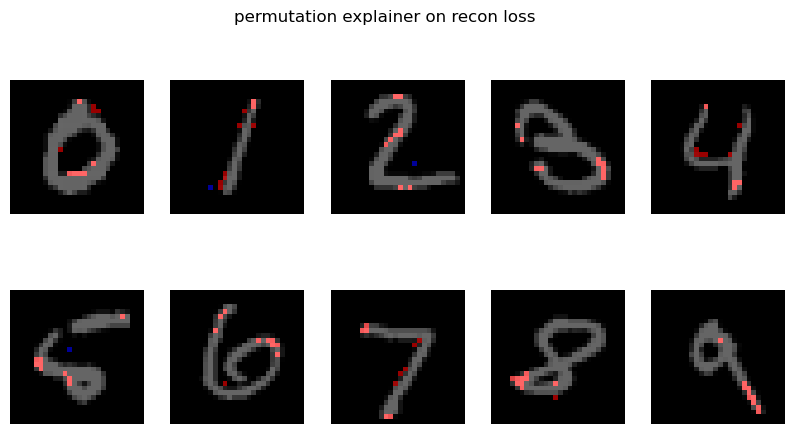

In [48]:
with open("shap/shap_on_real_dist/sv_perm_recon.pkl",'wb') as file:
    pickle.dump(shap_values_perm, file)
overlay_features(shap_values_perm,"permutation explainer on recon loss")

In [15]:
## latent dims
shap_values_lat0_perm=[]
shap_values_lat1_perm=[]
for i in range(10):
    batch=min(len(x_train[y_train==i]), 128)
    explainer=shap.PermutationExplainer(
        latent_wrapper_dim0,
        x_train[y_train==i][:batch]
    )    
    shap_values=explainer.shap_values(x_test[y_test==i])
    shap_values_lat0_perm.append(shap_values)

    explainer=shap.PermutationExplainer(
        latent_wrapper_dim1,
        x_train[y_train==i][:batch]
    )    
    shap_values=explainer.shap_values(x_test[y_test==i])
    shap_values_lat1_perm.append(shap_values)

PermutationExplainer explainer: 9it [01:24, 12.05s/it]                                           
PermutationExplainer explainer: 9it [01:24, 12.01s/it]                                           
PermutationExplainer explainer: 15it [02:00,  9.24s/it]                                          
PermutationExplainer explainer: 15it [02:00,  9.27s/it]                                          
PermutationExplainer explainer: 9it [01:21, 11.64s/it]                                           
PermutationExplainer explainer: 9it [01:21, 10.20s/it]                                           
PermutationExplainer explainer: 12it [01:47,  9.79s/it]                                          
PermutationExplainer explainer: 12it [01:47,  9.73s/it]                                          
PermutationExplainer explainer: 15it [02:04,  9.56s/it]                                          
PermutationExplainer explainer: 15it [02:04,  9.61s/it]                                          
PermutationExplainer

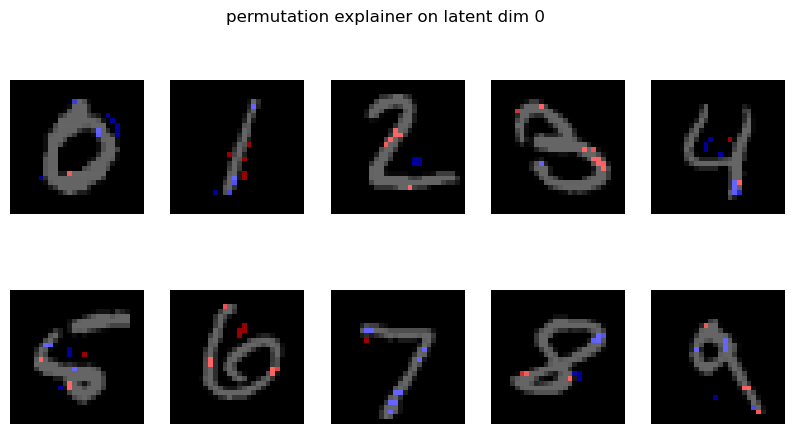

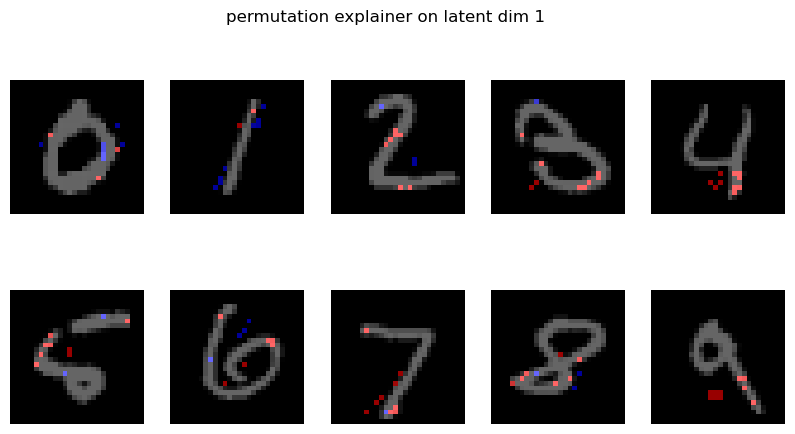

In [49]:
with open("shap/shap_on_real_dist/sv_perm_lat0.pkl",'wb') as file:
    pickle.dump(shap_values_lat0_perm, file)
overlay_features(shap_values_lat0_perm,"permutation explainer on latent dim 0")

with open("shap/shap_on_real_dist/sv_perm_lat1.pkl",'wb') as file:
    pickle.dump(shap_values_lat1_perm, file)
overlay_features(shap_values_lat1_perm,"permutation explainer on latent dim 1")

In [ ]:
### sampling explainer
# can pass in the entire training set since it samples anyways

## recon
shap_values_samp=[]
for i in range(10):
    batch=min(len(x_train[y_train==i]), 128)
    explainer=shap.SamplingExplainer(
        recon_error,
        x_train[y_train==i][:batch]
    )    
    shap_values=explainer.shap_values(x_test[y_test==i])
    shap_values_samp.append(shap_values)

In [19]:
with open("shap/shap_on_real_dist/sv_samp_recon.pkl",'wb') as file:
    pickle.dump(shap_values_samp, file)

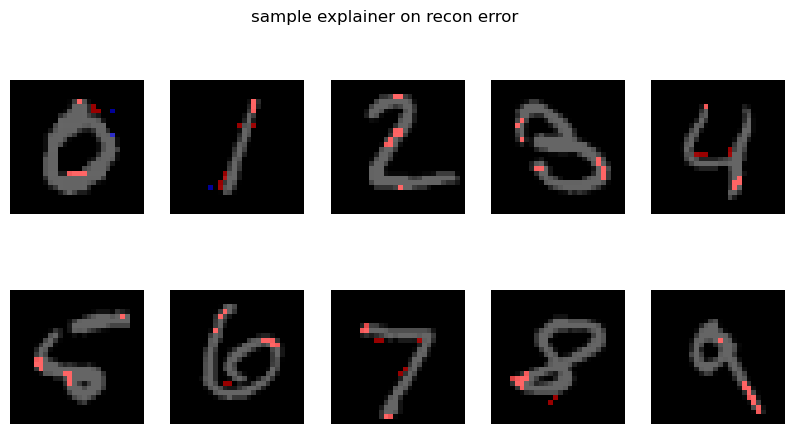

In [50]:
overlay_features(shap_values_samp, "sample explainer on recon error")

In [ ]:
## latent
shap_values_lat0_samp=[]
shap_values_lat1_samp=[]
for i in range(10):
    batch=min(len(x_train[y_train==i]), 128)
    explainer=shap.SamplingExplainer(
        latent_wrapper_dim0,
        x_train[y_train==i][:batch]
    )    
    shap_values=explainer.shap_values(x_test[y_test==i])
    shap_values_lat0_samp.append(shap_values)

    explainer=shap.SamplingExplainer(
        latent_wrapper_dim1,
        x_train[y_train==i][:batch]
    )    
    shap_values=explainer.shap_values(x_test[y_test==i])
    shap_values_lat1_samp.append(shap_values)

In [12]:
with open("shap/shap_on_real_dist/sv_samp_lat0.pkl",'wb') as file:
    pickle.dump(shap_values_lat0_samp, file)
with open("shap/shap_on_real_dist/sv_samp_lat1.pkl",'wb') as file:
    pickle.dump(shap_values_lat1_samp, file)

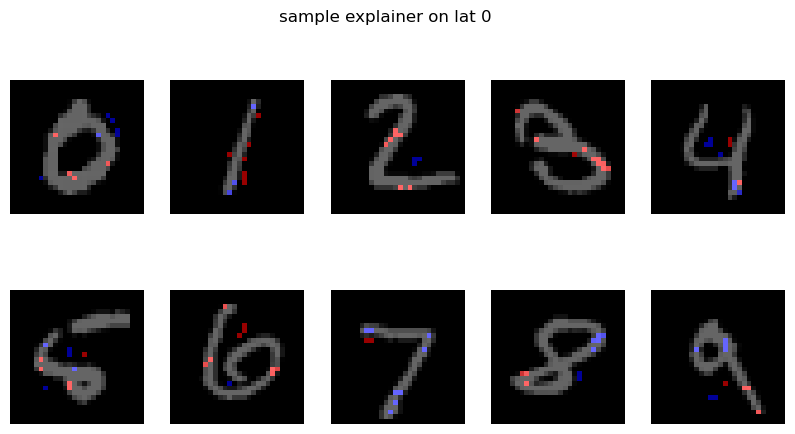

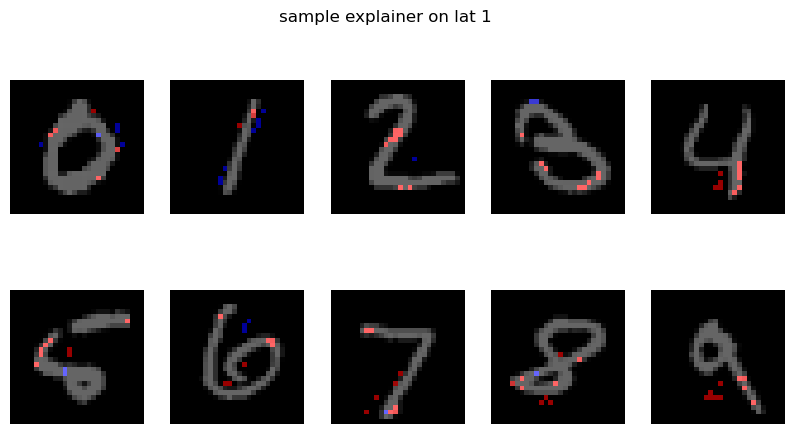

In [51]:
overlay_features(shap_values_lat0_samp,"sample explainer on lat 0")
overlay_features(shap_values_lat1_samp,"sample explainer on lat 1")

In [57]:
### gradient explainer
#currently returns shap values that are 0

wrapped_model=ModelWrapper_recon(model.model)
## recon
shap_values_grad=[]
for i in range(10):
    batch=min(len(x_train[y_train==i]), 128)
    ten=torch.tensor(x_train[y_train==i][:batch], dtype=torch.float32)
    explainer=shap.GradientExplainer(
        wrapped_model,
        ten
    )    
    test_ten=torch.tensor(x_test[y_test==i], dtype=torch.float32)
    shap_values=explainer.shap_values(test_ten)
    shap_values_grad.append(shap_values)

In [60]:
with open("./shap/shap_on_real_dist/sv_grad_recon.pkl", 'wb') as file:
    pickle.dump(shap_values_grad, file)

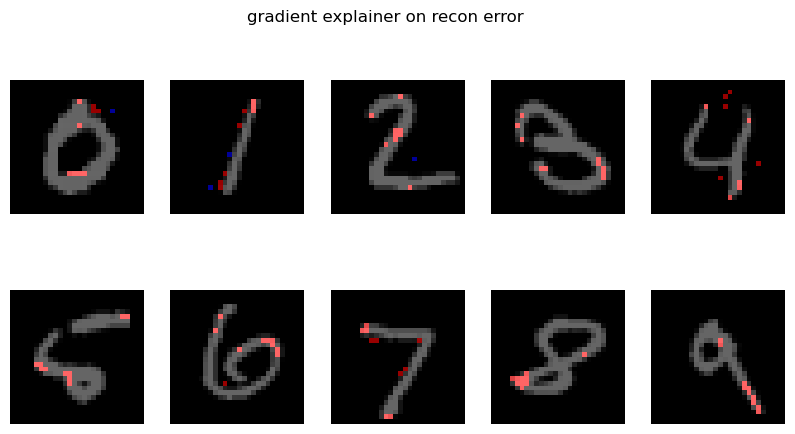

In [58]:
overlay_features(shap_values_grad,"gradient explainer on recon error")

In [82]:
wrapped_model_lat0=ModelWrapper_lat0(model.model)
wrapped_model_lat1=ModelWrapper_lat1(model.model)

shap_values_lat0_grad=[]
shap_values_lat1_grad=[]
for i in range(10):
    print(i)
    batch=min(len(x_train[y_train==i]), 128)
    ten=torch.tensor(x_train[y_train==i][:batch], dtype=torch.float32)
    explainer=shap.GradientExplainer(
        wrapped_model_lat0,
        ten
    )    
    test_ten=torch.tensor(x_test[y_test==i], dtype=torch.float32)
    shap_values=explainer.shap_values(test_ten)
    shap_values_lat0_grad.append(shap_values)

    explainer=shap.GradientExplainer(
        wrapped_model_lat1,
        ten
    ) 
    shap_values=explainer.shap_values(test_ten)
    shap_values_lat1_grad.append(shap_values)

0
1
2
3
4
5
6
7
8
9


In [84]:
with open("./shap/shap_on_real_dist/sv_grad_lat0.pkl", 'wb') as file:
    pickle.dump(shap_values_lat0_grad, file)
with open("./shap/shap_on_real_dist/sv_grad_lat1.pkl", 'wb') as file:
    pickle.dump(shap_values_lat1_grad, file)

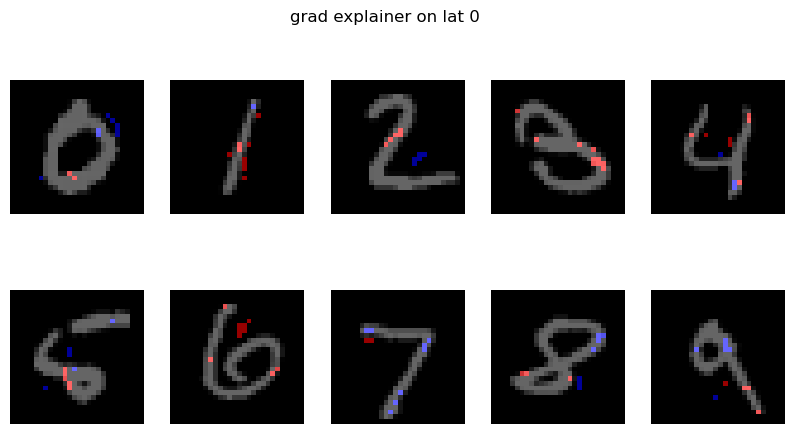

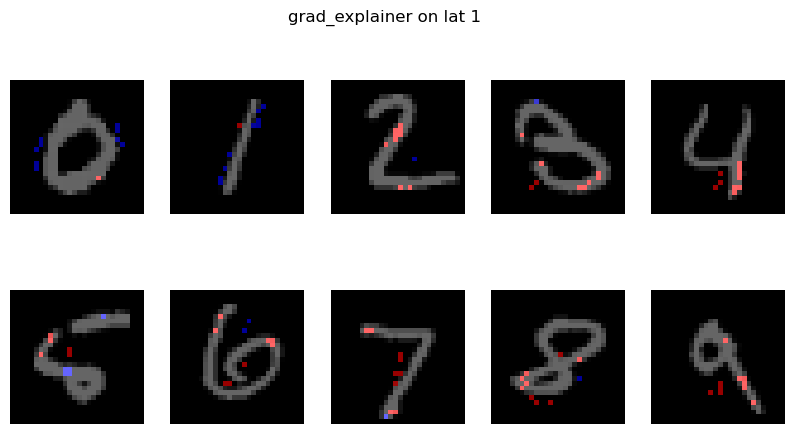

In [85]:
overlay_features(shap_values_lat0_grad,"grad explainer on lat 0")
overlay_features(shap_values_lat1_grad,"grad_explainer on lat 1")

In [90]:
### global interpretation 

# kernel
mean_shap_values_kernel=[shap_values_kernel[i].mean(axis=0) for i in range(10)]
mean_shap_values_lat0_kernel=[shap_values_lat0_kernel[i].mean(axis=0) for i in range(10)]
mean_shap_values_lat1_kernel=[shap_values_lat1_kernel[i].mean(axis=0) for i in range(10)]

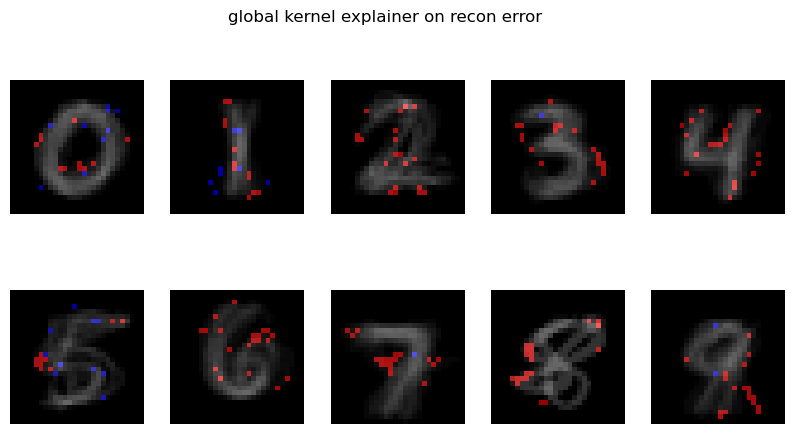

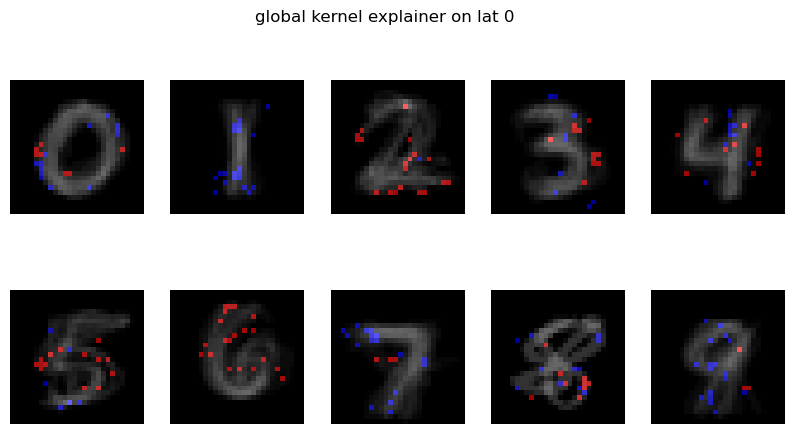

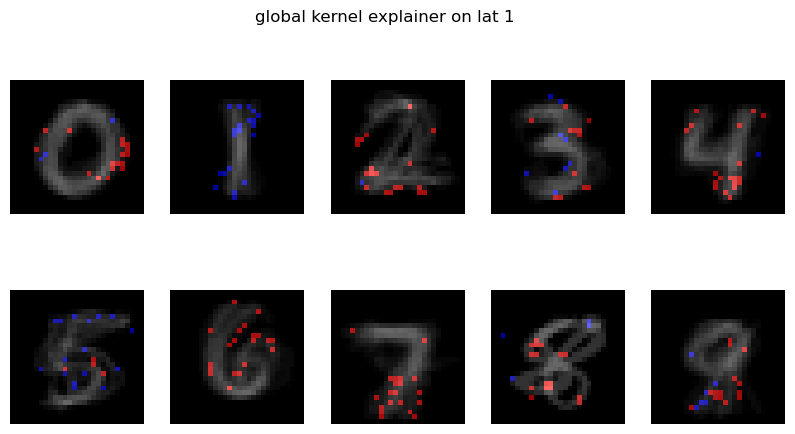

In [98]:
global_overlay_features(mean_shap_values_kernel,"global kernel explainer on recon error",20)
global_overlay_features(mean_shap_values_lat0_kernel,"global kernel explainer on lat 0",20)
global_overlay_features(mean_shap_values_lat1_kernel,"global kernel explainer on lat 1",20)

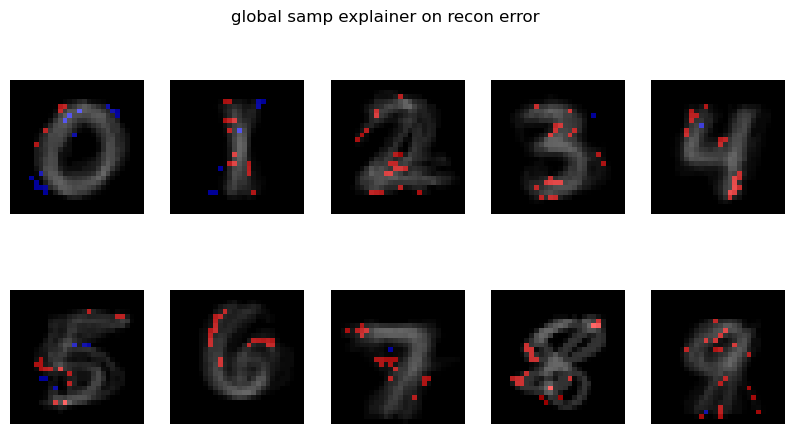

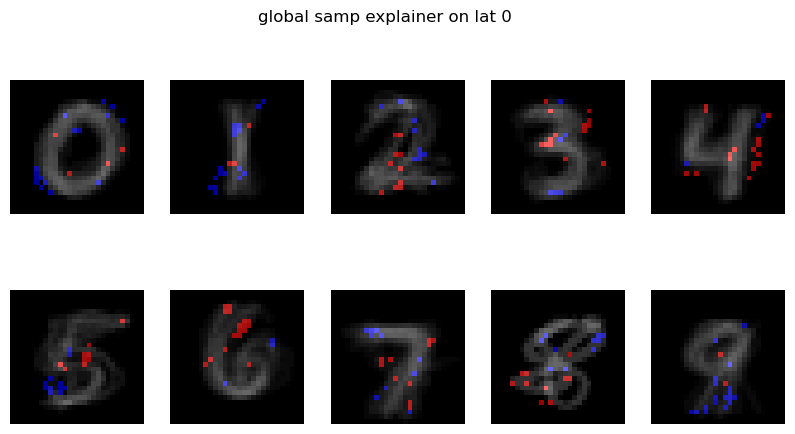

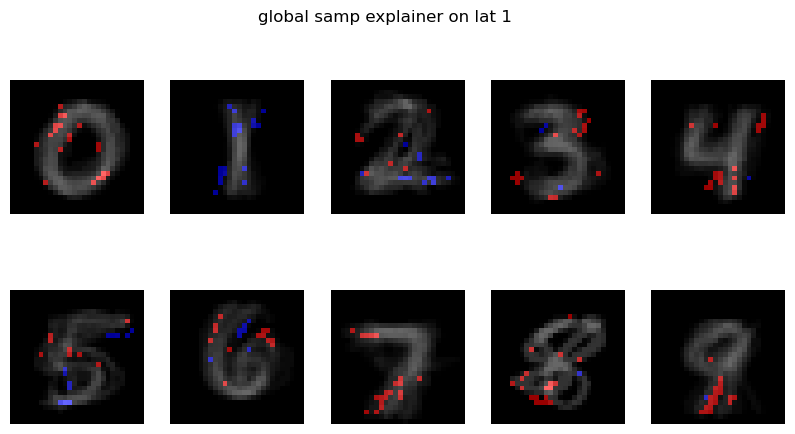

In [97]:
# samp
mean_shap_values_samp=[shap_values_samp[i].mean(axis=0) for i in range(10)]
mean_shap_values_lat0_samp=[shap_values_lat0_samp[i].mean(axis=0) for i in range(10)]
mean_shap_values_lat1_samp=[shap_values_lat1_samp[i].mean(axis=0) for i in range(10)]

global_overlay_features(mean_shap_values_samp,"global samp explainer on recon error",20)
global_overlay_features(mean_shap_values_lat0_samp,"global samp explainer on lat 0",20)
global_overlay_features(mean_shap_values_lat1_samp,"global samp explainer on lat 1",20)

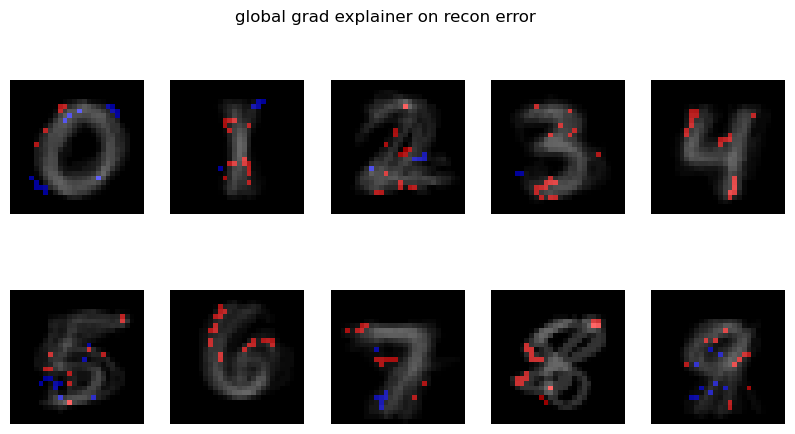

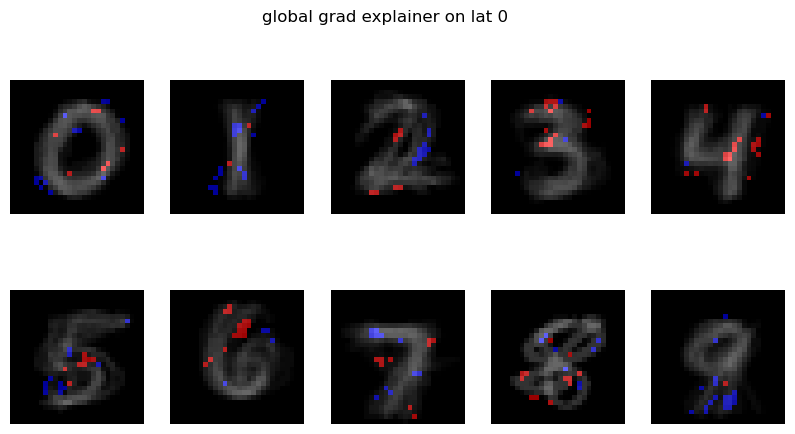

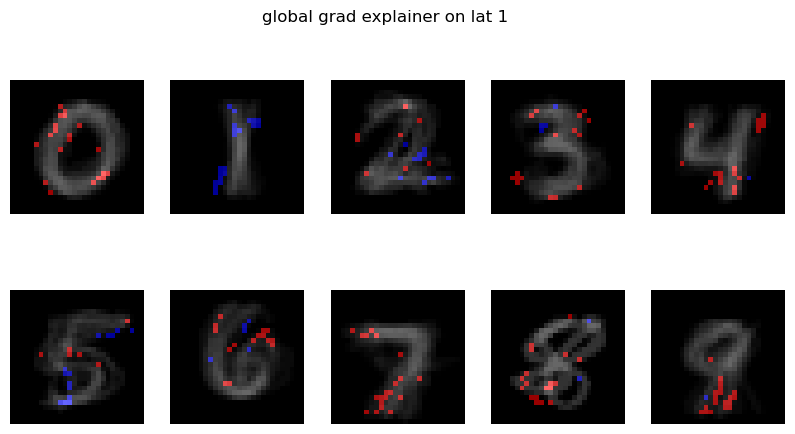

In [95]:
mean_shap_values_grad=[shap_values_grad[i].mean(axis=0) for i in range(10)]
mean_shap_values_lat0_grad=[shap_values_lat0_grad[i].mean(axis=0) for i in range(10)]
mean_shap_values_lat1_grad=[shap_values_lat1_grad[i].mean(axis=0) for i in range(10)]

global_overlay_features(mean_shap_values_grad,"global grad explainer on recon error",20)
global_overlay_features(mean_shap_values_lat0_grad,"global grad explainer on lat 0",20)
global_overlay_features(mean_shap_values_lat1_grad,"global grad explainer on lat 1",20)

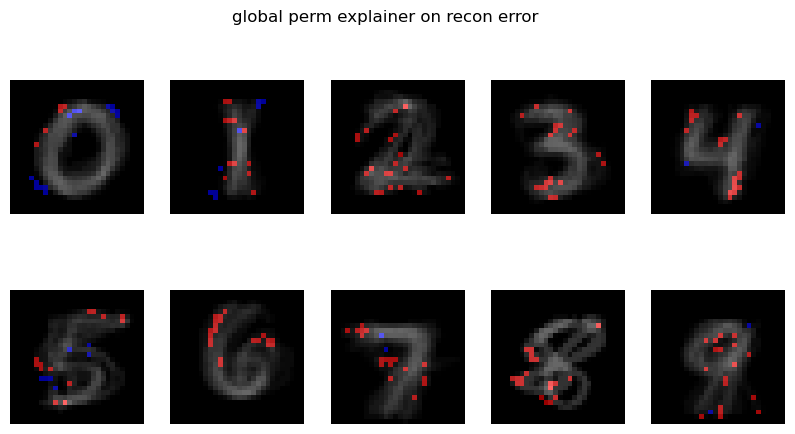

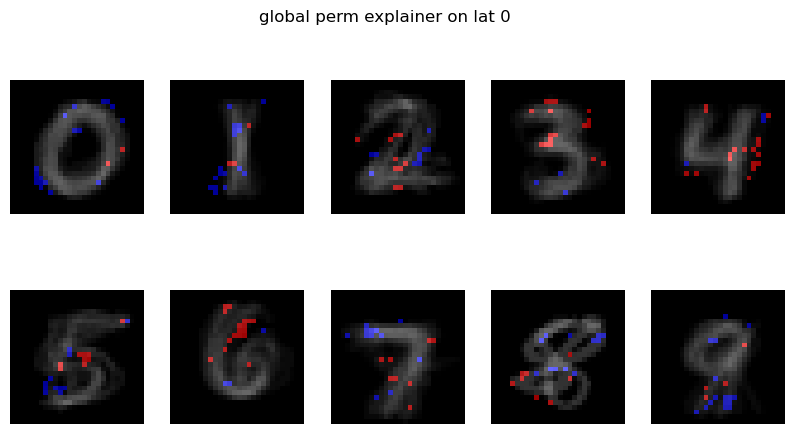

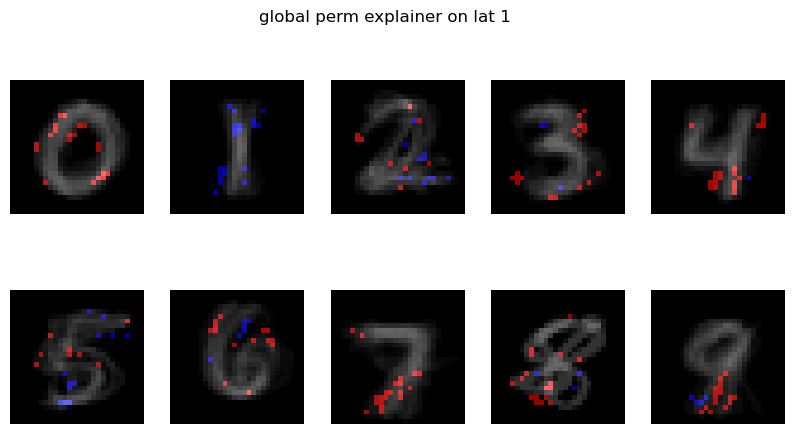

In [96]:
# perm 
mean_shap_values_perm=[shap_values_perm[i].mean(axis=0) for i in range(10)]
mean_shap_values_lat0_perm=[shap_values_lat0_perm[i].mean(axis=0) for i in range(10)]
mean_shap_values_lat1_perm=[shap_values_lat1_perm[i].mean(axis=0) for i in range(10)]

global_overlay_features(mean_shap_values_perm,"global perm explainer on recon error",20)
global_overlay_features(mean_shap_values_lat0_perm,"global perm explainer on lat 0",20)
global_overlay_features(mean_shap_values_lat1_perm,"global perm explainer on lat 1",20)